<a href="https://colab.research.google.com/github/Carmen10-171/01MIAR_ABR26/blob/main/01MIAR_PR02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Your imports HERE !!!!
import pandas as pd
import numpy as np
from pandas import Series, DataFrame
import sys
print(sys.executable)
!{sys.executable} -m pip install matplotlib

import matplotlib.pyplot as plt
# Seaborn es la librería para hacer gráficos
import sys
print(sys.executable)
!{sys.executable} -m pip install seaborn

import seaborn as sns


C:\Users\ccope\miniconda3\python.exe
C:\Users\ccope\miniconda3\python.exe


## DataFrame ordenado

- Escribe un generador `sort_by(df, column)` que devuelva las filas del dataframe `df` ordenadas de mayor a menor según la columna `column` que se pase como argumento.

In [ ]:
# Your solution HERE !!!!
def sort_by(df,column):
    df=df.sort_values(by=column,ascending = False)
    display(df)
    for i in range(len(df)):
        row =df.iloc[i]
        yield row


In [ ]:
# Test Use Case
players = pd.DataFrame({
    "Name": ["LeBron James", "Anthony Davis", "D'Angelo Russell", "Austin Reaves", "Jarred Vanderbilt", "Jaxson Hayes", "Rui Hachimura", "Spencer Dinwiddie", "Christian Wood", "Gabe Vincent", "Max Christie", "Cam Reddish"],
    "Height": [2.06, 2.08, 1.93, 1.96, 2.03, 2.11, 2.02, 1.95, 2.09, 1.91, 1.97, 2.01],
    "Weight": [224, 198, 203, 235, 160, 212, 185, 241, 196, 186, 199, 236],
    "Points": [25, 48, 12, 29, 23, 51, 27, 46, 3, 19, 11, 33],
})

g = sort_by(players, "Points")

expected_output = [212, 198, 241, 236, 235, 185, 224, 160, 186, 203, 199, 196]
output = [int(df_row["Weight"]) for df_row in g]

print(expected_output)
print(output)

assert(expected_output == output) # This will fail if the list is wrong

,Name,Height,Weight,Points
5,Jaxson Hayes,2.11,212,51
1,Anthony Davis,2.08,198,48
7,Spencer Dinwiddie,1.95,241,46
11,Cam Reddish,2.01,236,33
3,Austin Reaves,1.96,235,29
6,Rui Hachimura,2.02,185,27
0,LeBron James,2.06,224,25
4,Jarred Vanderbilt,2.03,160,23
9,Gabe Vincent,1.91,186,19
2,D'Angelo Russell,1.93,203,12


[212, 198, 241, 236, 235, 185, 224, 160, 186, 203, 199, 196]
[212, 198, 241, 236, 235, 185, 224, 160, 186, 203, 199, 196]


## Creando categorías
Dado el dataframe `players`, cambiar los datos en las columnas **Height** y **Weight** a variables categóricas a través de la función `categorizar`.
 - En la columna **Height**, los jugadores se dividirán a la mitad según su estatura. Los jugadores mas altos deben recibir la categoría *alto*, mientras que el resto obtendrá la categoría *bajo*.
 - En la columna **Weight**, todos los jugadores con peso mayor o igual a 200 kg serán categorizados cómo *pesado*, mientras que el resto cómo *liviano*.

In [ ]:
# Your solution HERE !!!!
import pandas as pd

def categorizar(df):
     mitad_altura = players["Height"].median()
     print(mitad_altura)
     df["Height"] = (pd.cut(df["Height"], bins=[0, mitad_altura, df["Height"].max()], labels=["bajo", "alto"])).astype(str)

     #div_datos = pd.cut(players["Height"], bins=[0, mitad_altura, players["Height"].max()], labels=["bajo", "alto"]).astype(str)
     #print(div_datos)

     peso = 200
     print(peso)
     df["Weight"] = (pd.cut(df["Weight"], bins=[0, peso, df["Weight"].max()], labels=["liviano", "pesado"])).astype(str)

     #div_datos_peso   = pd.cut(players["Weight"], bins=[0, peso, players["Weight"].max()], labels=["liviano", "pesado"]).astype(str)

     return df

     #def categorizar(df):
     #mitad_altura = df["Height"].median()
     #df["Height"] = (pd.cut(df["Height"], bins=[0, mitad_altura, df["Height"].max()], labels=["bajo", "alto"])).astype(str)
     #peso = 200
     #df["Weight"] = (pd.cut(df["Weight"], bins=[0, peso, df["Weight"].max()], labels=["liviano", "pesado"])).astype(str)
     #return df



In [ ]:
# Test Use Case
players = pd.DataFrame({
    "Name": ["LeBron James", "Anthony Davis", "D'Angelo Russell", "Austin Reaves", "Jarred Vanderbilt", "Jaxson Hayes", "Rui Hachimura", "Spencer Dinwiddie", "Christian Wood", "Gabe Vincent", "Max Christie", "Cam Reddish"],
    "Height": [2.06, 2.08, 1.93, 1.96, 2.03, 2.11, 2.02, 1.95, 2.09, 1.91, 1.97, 2.01],
    "Weight": [224, 198, 203, 235, 160, 212, 185, 241, 196, 186, 199, 236],
    "Points": [25, 48, 12, 29, 23, 51, 27, 46, 3, 19, 11, 33],
})

expected_output = pd.DataFrame({
    "Name": ["LeBron James", "Anthony Davis", "D'Angelo Russell", "Austin Reaves", "Jarred Vanderbilt", "Jaxson Hayes", "Rui Hachimura", "Spencer Dinwiddie", "Christian Wood", "Gabe Vincent", "Max Christie", "Cam Reddish"],
    "Height": ["alto", "alto", "bajo", "bajo", "alto", "alto", "alto", "bajo", "alto", "bajo", "bajo", "bajo"],
    "Weight": ["pesado", "liviano", "pesado", "pesado", "liviano", "pesado", "liviano", "pesado", "liviano", "liviano", "liviano", "pesado"],
    "Points": [25, 48, 12, 29, 23, 51, 27, 46, 3, 19, 11, 33],
})

output = categorizar(players)

display(expected_output)
print()
display(output)

assert(expected_output.equals(output))

2.0149999999999997
200


,Name,Height,Weight,Points
0,LeBron James,alto,pesado,25
1,Anthony Davis,alto,liviano,48
2,D'Angelo Russell,bajo,pesado,12
3,Austin Reaves,bajo,pesado,29
4,Jarred Vanderbilt,alto,liviano,23
5,Jaxson Hayes,alto,pesado,51
6,Rui Hachimura,alto,liviano,27
7,Spencer Dinwiddie,bajo,pesado,46
8,Christian Wood,alto,liviano,3
9,Gabe Vincent,bajo,liviano,19


,Name,Height,Weight,Points
0,LeBron James,alto,pesado,25
1,Anthony Davis,alto,liviano,48
2,D'Angelo Russell,bajo,pesado,12
3,Austin Reaves,bajo,pesado,29
4,Jarred Vanderbilt,alto,liviano,23
5,Jaxson Hayes,alto,pesado,51
6,Rui Hachimura,alto,liviano,27
7,Spencer Dinwiddie,bajo,pesado,46
8,Christian Wood,alto,liviano,3
9,Gabe Vincent,bajo,liviano,19


## Pivot Table

Del dataframe players con las columnas categorizadas, crear una función `pivotar` para mostrar el total y la media de puntos **Points**, según cada combinación posible de las categorías de estatura y peso.

In [ ]:
# Your solution HERE !!!!
def pivotar(df):

  return df.pivot_table('Points', index='Height', columns='Weight', aggfunc=['sum', 'mean'])



In [ ]:
# Test Use Case
players = pd.DataFrame({
    "Name": ["LeBron James", "Anthony Davis", "D'Angelo Russell", "Austin Reaves", "Jarred Vanderbilt", "Jaxson Hayes", "Rui Hachimura", "Spencer Dinwiddie", "Christian Wood", "Gabe Vincent", "Max Christie", "Cam Reddish"],
    "Height": ["alto", "alto", "bajo", "bajo", "alto", "alto", "alto", "bajo", "alto", "bajo", "bajo", "bajo"],
    "Weight": ["pesado", "liviano", "pesado", "pesado", "liviano", "pesado", "liviano", "pesado", "liviano", "liviano", "liviano", "pesado"],
    "Points": [25, 48, 12, 29, 23, 51, 27, 46, 3, 19, 11, 33],
})

output = pivotar(players)

display(output)

assert(output["sum"]["liviano"]["bajo"] == 30)
assert(round(output["mean"]["liviano"]["bajo"]) == 15)

sum           mean       
Weight liviano pesado liviano pesado
Height                              
alto       101     76   25.25   38.0
bajo        30    120   15.00   30.0

## Visualización

Junto con el notebook se ha añadido un fichero llamado `insurace.csv` donde se guardan datos de información médica y costo de un seguro de salud.

Tu tarea es:
1. Cargar el contenido en un dataframe.
2. Mostrar la correlación entre las columnas numéricas del dataframe y el costo del seguro (**charges**). ¿Qué columna muestra mayor correlación?
3. Mostar una regresión lineal entre el costo (**charges**, eje y) y la columna numérica con mayor correlación (eje x).
4. Visualizar con un gráfico de cajas (boxplot), cómo varía el índice de masa corporal (**bmi**, eje y) según el género (**sex**, eje x) para pacientes fumadores y no fumadores (**smoker**).

In [ ]:
# 1. Cargar el contenido en un dataframe.
df = pd.read_csv("insurance.csv", sep =',',engine='python')
display(df.head(4))
df.info()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061


<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [ ]:
# 2. Mostrar la correlación entre las columnas numéricas del dataframe y el costo del seguro (**charges**).
# ¿Qué columna muestra mayor correlación?
corr_data = df.corr(numeric_only=True)
corr_values = corr_data.to_numpy(copy=True)
np.fill_diagonal(corr_values, np.nan)

corr_data =pd.DataFrame(corr_values,index=corr_data.index, columns=corr_data.columns)

max_corr_col=corr_data["charges"].idxmax()


In [ ]:
# 3. Mostar una regresión lineal entre el costo (**charges**, eje y) y la columna numérica con mayor correlación (eje x).
max_corr_col=corr_data["charges"].idxmax()

print(f"la maxima correlación es con la columna {max_corr_col}")
corr_data.style.background_gradient(cmap=plt.get_cmap('RdYlGn'), axis=1,vmin=-1, vmax=1)

la maxima correlación es con la columna age


,age,bmi,children,charges
age,nan,0.109272,0.042469,0.299008
bmi,0.109272,nan,0.012759,0.198341
children,0.042469,0.012759,nan,0.067998
charges,0.299008,0.198341,0.067998,nan


In [ ]:
# Visualizar con un gráfico de cajas (boxplot), cómo varía el índice de masa corporal (**bmi**, eje y) según el género (**sex**, eje x)
# para pacientes fumadores y no fumadores (**smoker**).

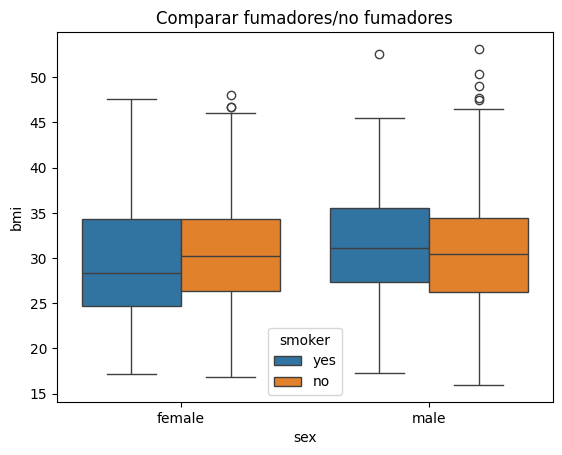

In [ ]:
sns.boxplot(x='sex', y='bmi', hue='smoker',data=df)
plt.title("Comparar fumadores/no fumadores")
plt.show()